In [1]:
%load_ext autoreload
%autoreload 2

# Random sampling

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import Waveform1PAT1R
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R

In [3]:
ode = Trajectory1PAT1R()

min_p = ode._min_p
max_p = ode._max_p

min_logm = -1.0
max_logm = 10.0

min_chi1 = ode._min_chi1
max_chi1 = ode._max_chi1

min_chi2 = ode._min_chi2
max_chi2 = ode._max_chi2

N_TESTS = 2000
dt = 1.   # time step [s]
T  = 100    # total duration [yr]

In [4]:
logm1 = np.random.uniform(min_logm, max_logm, N_TESTS)
logm2 = np.random.uniform(min_logm, max_logm, N_TESTS)
m1 = np.array([10.**np.max([logm1[i], logm2[i]]) for i in range(N_TESTS)])
m2 = np.array([10.**np.min([logm1[i], logm2[i]]) for i in range(N_TESTS)])
nu = m1 * m2 / (m1 + m2)**2.
chi1 = np.random.uniform(min_chi1, max_chi1, N_TESTS)
chi2 = np.random.uniform(min_chi2, max_chi2, N_TESTS)

p = np.array([np.random.uniform(*ode.bounds_p(0.0, 1.0, chi1[i], p_buffer=[0.01,0.0])) for i in range(N_TESTS)])

theta = np.random.uniform(0, np.pi, N_TESTS)
phi   = np.random.uniform(0, 2*np.pi, N_TESTS)

In [5]:
failed_indices = []
for i in range(N_TESTS):
    try:
        WF1PAT1R = Waveform1PAT1R()
        h1PAT1R = WF1PAT1R(m1[i], m2[i], chi1[i], p[i], theta[i], phi[i], chi2[i], dt=dt, T=T)
    except ValueError as e:
        print(f"  -> ValueError at i={i}: {e}")
        failed_indices.append(i)

print(f"\nFailed indices: {failed_indices}")


Failed indices: []


In [6]:
mask = np.ones(N_TESTS, dtype=bool)
mask[failed_indices] = False

nu_failed = nu[~mask]
chi1_failed = chi1[~mask]
chi2_failed = chi2[~mask]
p_failed = p[~mask]

nu_success = nu[mask]
chi1_success = chi1[mask]
chi2_success = chi2[mask]
p_success = p[mask]

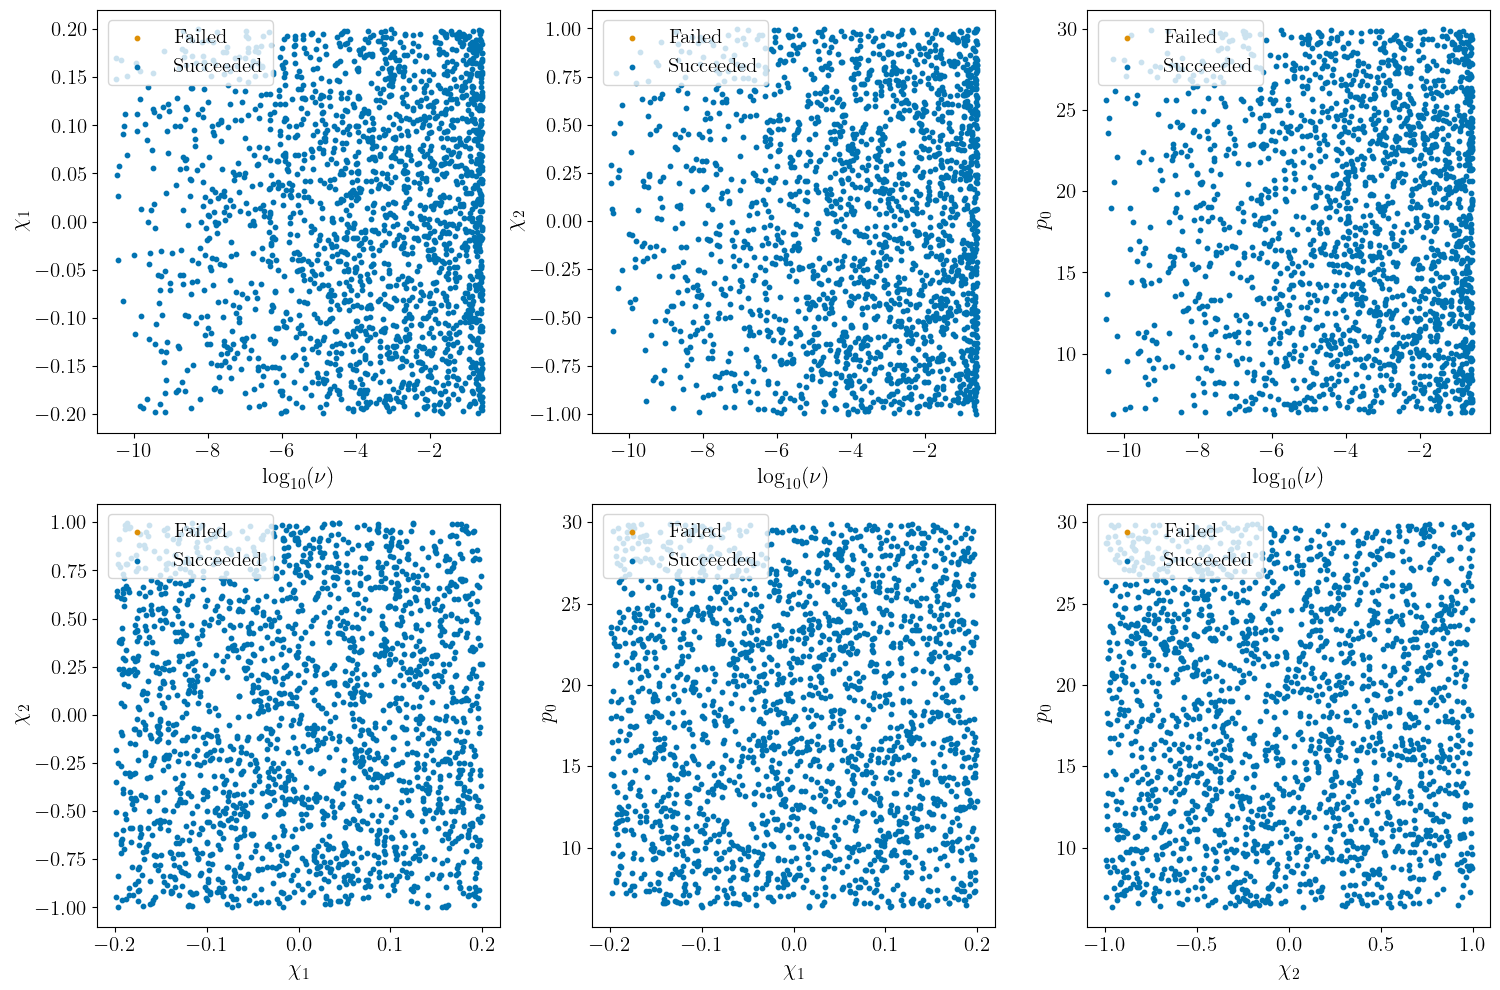

In [7]:
fontsize = 16
import seaborn as sns
colorblind_palette = sns.color_palette('colorblind')
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

colorblind_hex = [mcolors.to_hex(color) for color in colorblind_palette]

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]

fig, axs = plt.subplots(2,3,figsize=(15,10), tight_layout=True)

axs[0,0].scatter(np.log10(nu_failed), chi1_failed, color=colorblind_hex[1], label='Failed', s=10)
axs[0,0].scatter(np.log10(nu_success), chi1_success, color=colorblind_hex[0], label='Succeeded', s=10)
axs[0,0].set_xlabel(rf'$\log_{{10}}(\nu)$', fontsize=fontsize)
axs[0,0].set_ylabel(rf'$\chi_1$', fontsize=fontsize)
axs[0,0].legend(fontsize=fontsize-1, loc='upper left')
axs[0,0].tick_params(labelsize=fontsize-1)

axs[0,1].scatter(np.log10(nu_failed), chi2_failed, color=colorblind_hex[1], label='Failed', s=10)
axs[0,1].scatter(np.log10(nu_success), chi2_success, color=colorblind_hex[0], label='Succeeded', s=10)
axs[0,1].set_xlabel(rf'$\log_{{10}}(\nu)$', fontsize=fontsize)
axs[0,1].set_ylabel(rf'$\chi_2$', fontsize=fontsize)
axs[0,1].legend(fontsize=fontsize-1, loc='upper left')
axs[0,1].tick_params(labelsize=fontsize-1)

axs[0,2].scatter(np.log10(nu_failed), p_failed, color=colorblind_hex[1], label='Failed', s=10)
axs[0,2].scatter(np.log10(nu_success), p_success, color=colorblind_hex[0], label='Succeeded', s=10)
axs[0,2].set_xlabel(rf'$\log_{{10}}(\nu)$', fontsize=fontsize)
axs[0,2].set_ylabel(rf'$p_0$', fontsize=fontsize)
axs[0,2].legend(fontsize=fontsize-1, loc='upper left')
axs[0,2].tick_params(labelsize=fontsize-1)

axs[1,0].scatter(chi1_failed, chi2_failed, color=colorblind_hex[1], label='Failed', s=10)
axs[1,0].scatter(chi1_success, chi2_success, color=colorblind_hex[0], label='Succeeded', s=10)
axs[1,0].set_xlabel(rf'$\chi_1$', fontsize=fontsize)
axs[1,0].set_ylabel(rf'$\chi_2$', fontsize=fontsize)
axs[1,0].legend(fontsize=fontsize-1, loc='upper left')
axs[1,0].tick_params(labelsize=fontsize-1)

axs[1,1].scatter(chi1_failed, p_failed, color=colorblind_hex[1], label='Failed', s=10)
axs[1,1].scatter(chi1_success, p_success, color=colorblind_hex[0], label='Succeeded', s=10)
axs[1,1].set_xlabel(rf'$\chi_1$', fontsize=fontsize)
axs[1,1].set_ylabel(rf'$p_0$', fontsize=fontsize)
axs[1,1].legend(fontsize=fontsize-1, loc='upper left')
axs[1,1].tick_params(labelsize=fontsize-1)

axs[1,2].scatter(chi2_failed, p_failed, color=colorblind_hex[1], label='Failed', s=10)
axs[1,2].scatter(chi2_success, p_success, color=colorblind_hex[0], label='Succeeded', s=10)
axs[1,2].set_xlabel(rf'$\chi_2$', fontsize=fontsize)
axs[1,2].set_ylabel(rf'$p_0$', fontsize=fontsize)
axs[1,2].legend(fontsize=fontsize-1, loc='upper left')
axs[1,2].tick_params(labelsize=fontsize-1)

plt.show()

## Load and plot T = 100yr duration results

In [3]:
import h5py
success_path = "params_success_T100_dt5_N2000.h5";
fail_path = "params_fail_T100_dt5_N2000.h5"

keys = ['chi1', 'chi2', 'm1', 'm2', 'nu', 'p', 'phi', 'theta']

success_params = {}
try:
    with h5py.File(success_path) as hf:
        for key in keys:
            success_params[key] = np.array(hf.get(key));   
except FileNotFoundError:
    print(f"File not found: {success_path}");
    for key in keys:
        success_params[key] = [];

failed_params = {}
try:
    with h5py.File(fail_path) as hf:
        for key in keys:
            failed_params[key] = np.array(hf.get(key));   
except FileNotFoundError:
    print(f"File not found: {fail_path}");
    for key in keys:
        failed_params[key] = [];

File not found: params_fail_T100_dt5_N2000.h5


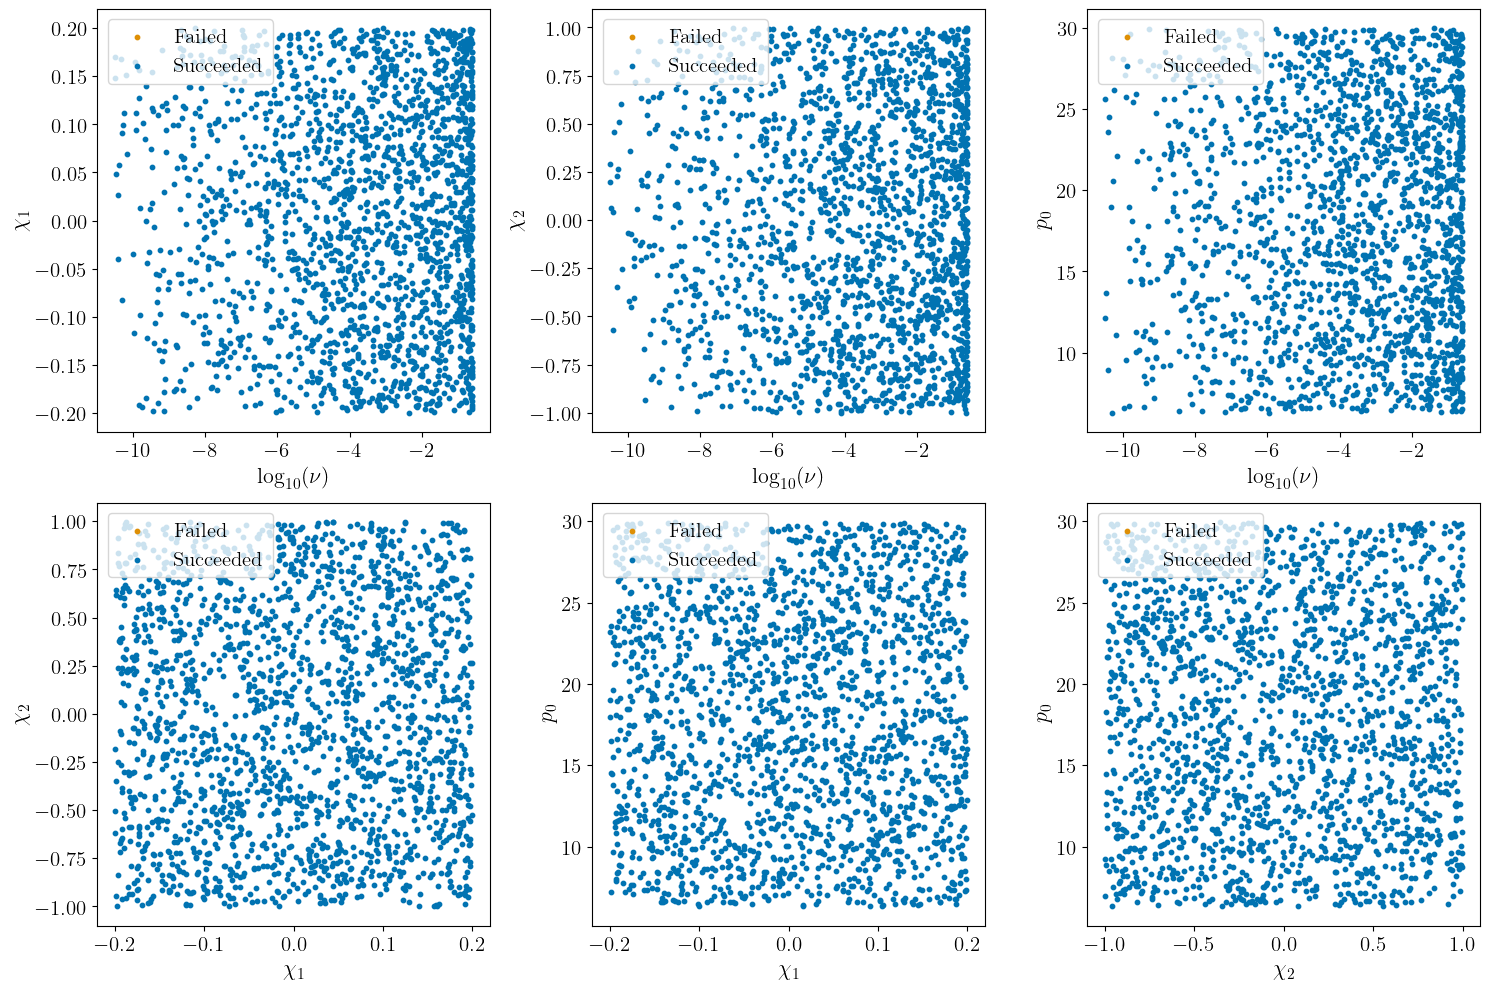

In [11]:
fontsize = 16
import seaborn as sns
colorblind_palette = sns.color_palette('colorblind')
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
colorblind_hex = [mcolors.to_hex(color) for color in colorblind_palette]

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]

fig, axs = plt.subplots(2,3,figsize=(15,10), tight_layout=True)

axs[0,0].scatter(np.log10(failed_params["nu"]), failed_params["chi1"], color=colorblind_hex[1], label='Failed', s=10)
axs[0,0].scatter(np.log10(success_params["nu"]), success_params["chi1"], color=colorblind_hex[0], label='Succeeded', s=10)
axs[0,0].set_xlabel(rf'$\log_{{10}}(\nu)$', fontsize=fontsize)
axs[0,0].set_ylabel(rf'$\chi_1$', fontsize=fontsize)
axs[0,0].legend(fontsize=fontsize-1, loc='upper left')
axs[0,0].tick_params(labelsize=fontsize-1)

axs[0,1].scatter(np.log10(failed_params["nu"]), failed_params["chi2"], color=colorblind_hex[1], label='Failed', s=10)
axs[0,1].scatter(np.log10(success_params["nu"]), success_params["chi2"], color=colorblind_hex[0], label='Succeeded', s=10)
axs[0,1].set_xlabel(rf'$\log_{{10}}(\nu)$', fontsize=fontsize)
axs[0,1].set_ylabel(rf'$\chi_2$', fontsize=fontsize)
axs[0,1].legend(fontsize=fontsize-1, loc='upper left')
axs[0,1].tick_params(labelsize=fontsize-1)

axs[0,2].scatter(np.log10(failed_params["nu"]), failed_params["p"], color=colorblind_hex[1], label='Failed', s=10)
axs[0,2].scatter(np.log10(success_params["nu"]), success_params["p"], color=colorblind_hex[0], label='Succeeded', s=10)
axs[0,2].set_xlabel(rf'$\log_{{10}}(\nu)$', fontsize=fontsize)
axs[0,2].set_ylabel(rf'$p_0$', fontsize=fontsize)
axs[0,2].legend(fontsize=fontsize-1, loc='upper left')
axs[0,2].tick_params(labelsize=fontsize-1)

axs[1,0].scatter(failed_params["chi1"], failed_params["chi2"], color=colorblind_hex[1], label='Failed', s=10)
axs[1,0].scatter(success_params["chi1"], success_params["chi2"], color=colorblind_hex[0], label='Succeeded', s=10)
axs[1,0].set_xlabel(rf'$\chi_1$', fontsize=fontsize)
axs[1,0].set_ylabel(rf'$\chi_2$', fontsize=fontsize)
axs[1,0].legend(fontsize=fontsize-1, loc='upper left')
axs[1,0].tick_params(labelsize=fontsize-1)

axs[1,1].scatter(failed_params["chi1"], failed_params["p"], color=colorblind_hex[1], label='Failed', s=10)
axs[1,1].scatter(success_params["chi1"], success_params["p"], color=colorblind_hex[0], label='Succeeded', s=10)
axs[1,1].set_xlabel(rf'$\chi_1$', fontsize=fontsize)
axs[1,1].set_ylabel(rf'$p_0$', fontsize=fontsize)
axs[1,1].legend(fontsize=fontsize-1, loc='upper left')
axs[1,1].tick_params(labelsize=fontsize-1)

axs[1,2].scatter(failed_params["chi2"], failed_params["p"], color=colorblind_hex[1], label='Failed', s=10)
axs[1,2].scatter(success_params["chi2"], success_params["p"], color=colorblind_hex[0], label='Succeeded', s=10)
axs[1,2].set_xlabel(rf'$\chi_2$', fontsize=fontsize)
axs[1,2].set_ylabel(rf'$p_0$', fontsize=fontsize)
axs[1,2].legend(fontsize=fontsize-1, loc='upper left')
axs[1,2].tick_params(labelsize=fontsize-1)

#plt.show()
plt.savefig("WaveformConvergence_T100.png", dpi=250)